In [1]:
import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter, CoxPHFitter
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sksurv.metrics import brier_score, integrated_brier_score
from sksurv.util import Surv
from sklearn.model_selection import train_test_split

### Models Used
1. Kaplan Meier: estimates probability that any random customer still subscribe after X months, using only subscription lengtth and churn flag. This answer "what does retention looks like accross  whole population?"

2. Cox PH: Estimates how much each feature (calls, complaint, etc) accelerate or decelerates the hazard of churning at any moment. Above 1 -> feature increases churn risk. Below 1 -> protective of churn. 

### Feature Engineering & Split  
1. Scaling (Divide by 10) because Coc PH is sensitive to coefficient magnitude. 
2. Split 80% train 20% test 

In [2]:
df_baseline = pd.read_csv("dataset/df_clean.csv")

df_baseline["Minutes of Use"] = df_baseline["Seconds of Use"] / 60
df_baseline["Charge Amount/10"] = df_baseline["Charge Amount"] / 10
df_baseline = df_baseline.drop(columns=["Seconds of Use", "Charge Amount"])

print(f"Shape: {df_baseline.shape}")
df_train, df_test = train_test_split(df_baseline, test_size=0.2, random_state=42)
print(f"Shape for training set: {df_train.shape}")
print(f"Shape for test set: {df_test.shape}")

Shape: (2850, 14)
Shape for training set: (2280, 14)
Shape for test set: (570, 14)


In [3]:
y_train = df_train[["Subscription Length", "Churn"]]

print("Baseline Target Structure: ")
print(y_train.head())

Baseline Target Structure: 
      Subscription Length  Churn
942                    15      0
598                    10      1
2676                   32      0
2212                   33      0
789                    20      0


### Kaplan Meier
- Fits only on train data to avoid leakage 
- Based on subs length and churn flag 

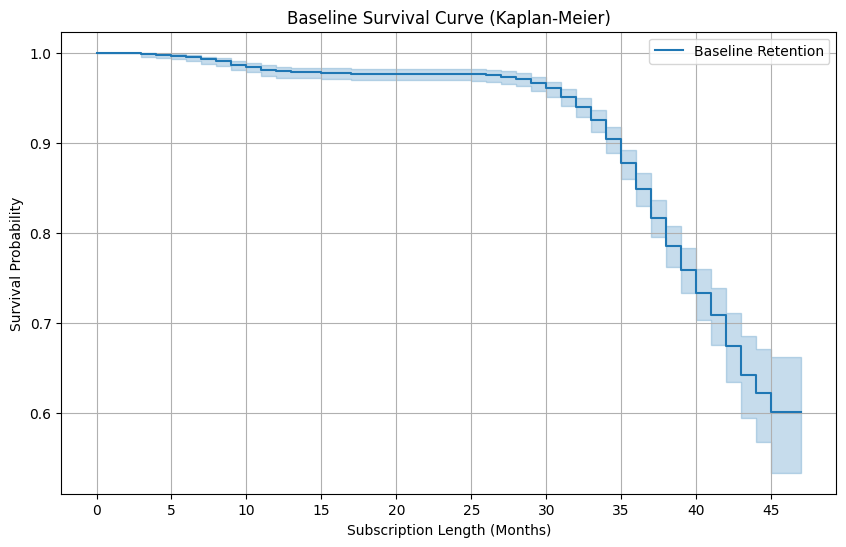

In [4]:
kmf = KaplanMeierFitter()

kmf.fit(durations=df_train["Subscription Length"], event_observed=df_train["Churn"], label="Baseline Retention"
)


plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title('Baseline Survival Curve (Kaplan-Meier)')
plt.xlabel('Subscription Length (Months)')
plt.ylabel('Survival Probability')
plt.xticks(np.arange(0, df_train["Subscription Length"].max()+1, 5))
plt.grid(True)
plt.show()

### Cox PH 
- Penalizer 0.01 adds L2 (ridge) regularization to Cox model for the model to generalize better

In [5]:
from sklearn.model_selection import KFold
import numpy as np
features = [
    "Call Failure",
    "Complains",
    "Charge Amount/10",
    "Minutes of Use",
    "Frequency of SMS",
    "Distinct Called Numbers",
    "Age",
    "Tariff Plan"
]
C = [0.01, 0.1, 1, 10, 100]
target_data = ["Subscription Length", "Churn"]

C = [0.01, 0.1, 1, 10, 100]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for c in C:
    fold_scores = []
    for train_idx, val_idx in kf.split(df_train):
        fold_train = df_train.iloc[train_idx]
        fold_val   = df_train.iloc[val_idx]

        cph = CoxPHFitter(penalizer=c)
        cph.fit(fold_train[features + target_data],
                duration_col="Subscription Length",
                event_col="Churn")

        score = cph.score(fold_val[features + target_data],
                          scoring_method="concordance_index")
        fold_scores.append(score)

    cv_results[c] = (np.mean(fold_scores), np.std(fold_scores))
    print(f"penalizer={c}:  mean C-index: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

best_c = max(cv_results, key=lambda c: cv_results[c][0])
print(f"\nBest penalizer: {best_c}")

# Retrain on full df_train with best_c and evaluate once on df_test
final_cph = CoxPHFitter(penalizer=best_c)
final_cph.fit(df_train[features + target_data],
              duration_col="Subscription Length", event_col="Churn")
final_score = final_cph.score(df_test[features + target_data],
                               scoring_method="concordance_index")
print(f"Final test C-index: {final_score:.4f}")

penalizer=0.01:  mean C-index: 0.8732 ± 0.0200
penalizer=0.1:  mean C-index: 0.8694 ± 0.0202
penalizer=1:  mean C-index: 0.8662 ± 0.0199
penalizer=10:  mean C-index: 0.8653 ± 0.0202
penalizer=100:  mean C-index: 0.8653 ± 0.0203

Best penalizer: 0.01
Final test C-index: 0.8709


                                 coef  exp(coef)         p
covariate                                                 
Call Failure            -3.534397e-05   0.999965  0.911386
Complains                7.419552e-03   1.007447  0.383528
Charge Amount/10        -5.904118e-03   0.994113  0.690004
Minutes of Use          -1.869062e-05   0.999981  0.578361
Frequency of SMS        -8.946668e-06   0.999991  0.676428
Distinct Called Numbers -6.451040e-05   0.999935  0.632209
Age                     -8.704431e-07   0.999999  0.997373
Tariff Plan             -6.528931e-04   0.999347  0.938343


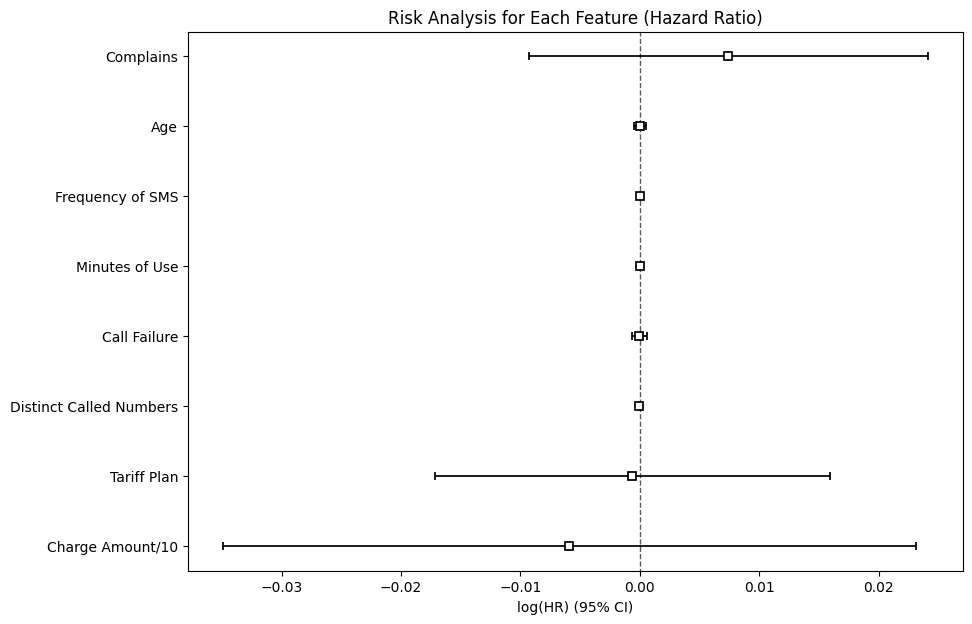

In [6]:
summary = cph.summary[["coef", "exp(coef)", "p"]]
print(summary)

plt.figure(figsize=(10, 7))
cph.plot()
plt.title("Risk Analysis for Each Feature (Hazard Ratio)")
plt.show()

In [7]:
print(f"C-Index Training: {cph.concordance_index_:.4f}")
print(f"C-Index Testing: {final_score:.4f}")

y_train = Surv.from_dataframe("Churn", "Subscription Length", df_train)
y_test = Surv.from_dataframe("Churn", "Subscription Length", df_test)

times = np.array([40])
pred_surv = cph.predict_survival_function(df_test, times=times)
surv_probs = pred_surv.values.T
times_val, score = brier_score(y_train, y_test, surv_probs, 40)

print(f"Brier Score at month 40: {score[0]:.4f}")

C-Index Training: 0.8680
C-Index Testing: 0.8709
Brier Score at month 40: 0.2423


In [10]:
min_time, max_time = np.percentile(y_test["Subscription Length"], [10, 90])
ibs_times = np.linspace(min_time, max_time, 50)

avg_pred_surv = cph.predict_survival_function(df_test, times=ibs_times)
surv_prob_mat = avg_pred_surv.values.T
ibs_score = integrated_brier_score(y_train, y_test, surv_prob_mat,  ibs_times)

print(f"Baseline Cox PH Integrated Brier Score (IBS): {ibs_score:.4f}")

Baseline Cox PH Integrated Brier Score (IBS): 0.0731
